# Problema 1. Monitoreo y recalibracion de sensores de calidad del aire

Dato de entrada: Air Quality (UCI, id 360), 9358 promedios horarios de cinco sensores quimicos y de sus analizadores de referencia.

Parametro latente: el sesgo actual del sensor respecto a la referencia.

Modelo: normal-normal conjugado con actualizacion recursiva, mas EM para la version multivariante con faltantes.

Salida verificable: posterior del sesgo, densidad predictiva de cada observacion nueva, alerta de anomalia y tiempo de deteccion de deriva.

---

## Como leer este cuaderno

Cada bloque de codigo va precedido por una celda que explica en palabras que hace, linea por linea cuando hace falta, y con que idea del capitulo 3 de Duda, Hart y Stork (*Pattern Classification*, 2.ª ed.) se conecta. Despues de las salidas importantes hay una celda de lectura que dice que mirar en la tabla o en la grafica y que significa.

La idea que organiza todo el cuaderno es la siguiente. Un sensor barato mide una senal $s_t$ y un analizador de referencia mide la concentracion real $y_t$. Con una recta de calibracion $g(s)$ se convierte la senal en concentracion, y lo que queda, $e_t = y_t - g(s_t)$, es el error de calibracion. Si el sensor esta bien calibrado, $e_t$ oscila alrededor de cero. Si el sensor se desajusta, el centro de $e_t$ se mueve. Ese centro es el parametro desconocido $\mu$ del capitulo, y la pregunta del problema es como estimarlo, como actualizarlo a medida que llegan datos y como saber cuando cambio.

## Mapa entre el cuaderno y el capitulo 3

| Seccion del cuaderno | Idea del capitulo | Donde esta en el libro |
|---|---|---|
| 5. Calibracion nominal | El modelo parametrico se fija antes de estimar; aqui $e_t \sim \mathcal{N}(\mu, \sigma^2)$ | 3.1 y 3.2 |
| 6. Actualizacion bayesiana recursiva | Estimacion bayesiana de la media de una normal con varianza conocida: previa $\mathcal{N}(\mu_0, \sigma_0^2)$, posterior $\mathcal{N}(\mu_n, \sigma_n^2)$ | 3.4.1 |
| 6. Densidad predictiva | $p(x \mid D) = \int p(x \mid \mu)\, p(\mu \mid D)\, d\mu$, que para la normal da $\mathcal{N}(\mu_n, \sigma^2 + \sigma_n^2)$ | 3.3 y 3.4.2 |
| 6. Actualizacion sin guardar el historico | Aprendizaje bayesiano recursivo y estadisticas suficientes ($n$ y $\sum e_i$) | 3.5 y 3.6 |
| 7. Alerta probabilistica | La predictiva como criterio de que tan sorprendente es un dato nuevo | 3.3 |
| 10. MLE frente a Bayes | Con pocos datos la previa importa; con muchos, la posterior y el MLE coinciden | 3.2.2 y 3.5.1 |
| 11. EM multivariante | Expectation-Maximization para estimar $\mu$ y $\Sigma$ con entradas faltantes | 3.9 |
| 13. Diagnostico | Las hipotesis del capitulo: observaciones i.i.d., forma parametrica correcta, $\sigma^2$ conocida | 3.1 y 3.7 |

## Notacion

$s_t$ es la lectura del sensor, $y_t$ la referencia, $e_t$ el error de calibracion. $\mu$ es el sesgo verdadero del sensor, desconocido. $\mu_0$ y $\sigma_0^2$ son la media y la varianza de la previa. $\mu_n$ y $\sigma_n^2$ son la media y la varianza de la posterior despues de $n$ datos. $\sigma^2$ es la varianza del ruido, que el capitulo trata como conocida y aqui se estima una sola vez en el tramo de calibracion. $D_n$ es el conjunto de los primeros $n$ errores observados.

**Que hace esta celda.** Instala las cuatro librerias que usa el cuaderno. `ucimlrepo` descarga conjuntos del repositorio de UCI con una sola llamada; `numpy` hace el algebra; `pandas` organiza tablas; `matplotlib` dibuja. No se usa ninguna libreria estadistica de alto nivel a proposito: la actualizacion bayesiana y el EM se programan a mano para que las formulas del capitulo queden visibles en el codigo.

In [19]:
!pip install ucimlrepo numpy pandas matplotlib

  Using cached matplotlib-3.11.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.64.0-cp314-cp314-macosx_10_15_universal2.whl.metadata (123 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp314-cp314-macosx_11_0_arm64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.64.0-cp314-cp314-macosx_10_15_universal2.whl (3.1 MB)
Using cached kiwisolver-1.5.1-cp314-cp314-macosx_11_0_arm64.whl (64 kB)
Using cached pillow-12.3.0-cp314-cp314-macosx_11_0_arm64.whl (4.8 MB)
Using cached pyparsing-3.3.2

**Que hace esta celda.** Importa las librerias y fija dos cosas que garantizan reproducibilidad: una semilla (`SEED = 7`) para cualquier sorteo aleatorio, y opciones de presentacion de pandas y matplotlib para que las tablas y las figuras salgan con el mismo formato en todas las secciones. `rng` es el generador de numeros aleatorios que se usara mas adelante; crear uno con semilla fija hace que dos corridas del cuaderno den los mismos numeros.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

SEED = 7
rng = np.random.default_rng(SEED)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (11, 3.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

## 1. Carga y construccion del indice temporal

Se une `Date` y `Time` en una marca de tiempo, se ordena cronologicamente y se descartan las filas sin fecha valida.

**Que hace esta celda.** Descarga el conjunto Air Quality (id 360 en UCI) y guarda una copia de la tabla original en `crudo`. `.copy()` evita modificar por accidente el objeto que devuelve la libreria. La salida `(9357, 15)` dice que hay 9357 promedios horarios y 15 columnas.

**Conexion con el libro.** El capitulo 3 empieza suponiendo que se dispone de una muestra $D = \{x_1, \dots, x_n\}$ extraida de una densidad de forma conocida con parametros desconocidos. Esta celda es la que trae esa muestra. Todo lo que sigue es decidir que forma parametrica tiene y como estimar sus parametros.

In [21]:
air_quality = fetch_ucirepo(id=360)
crudo = air_quality.data.original.copy()
crudo.shape

(9357, 15)

**Que hace esta celda.** Lista los nombres de las columnas para identificar los pares sensor y referencia. Las columnas con `(GT)` (*ground truth*) son las concentraciones medidas por el analizador de referencia certificado. Las columnas `PT08.Sx(...)` son las respuestas de los cinco sensores de bajo costo, en unidades propias del dispositivo, no en concentracion. `T`, `RH` y `AH` son temperatura, humedad relativa y humedad absoluta.

In [22]:
crudo.columns.tolist()

['Date',
 'Time',
 'CO(GT)',
 'PT08.S1(CO)',
 'NMHC(GT)',
 'C6H6(GT)',
 'PT08.S2(NMHC)',
 'NOx(GT)',
 'PT08.S3(NOx)',
 'NO2(GT)',
 'PT08.S4(NO2)',
 'PT08.S5(O3)',
 'T',
 'RH',
 'AH']

**Que hace esta celda.** Construye un indice temporal. El archivo trae la fecha y la hora en dos columnas de texto (`Date` y `Time`, con la hora escrita como `18.00.00`). Paso a paso:

1. `fecha` y `hora` limpian espacios y cambian los puntos de la hora por dos puntos para que pandas la entienda.
2. `pd.to_datetime(..., dayfirst=True)` combina ambas en una marca de tiempo; si mas de la mitad no se pudiera interpretar, se reintenta sin `dayfirst`.
3. La rama `else` es un plan de contingencia: si el archivo no trajera fecha, se fabrica una secuencia horaria para que el cuaderno pueda correr.
4. Se descartan las filas sin fecha valida y se ordena cronologicamente.

**Por que importa el orden.** Todo el problema es secuencial: la posterior se actualiza dato a dato en el orden en que llegan. Si las filas estuvieran desordenadas, la "deriva" que se detectara seria un artefacto del desorden. La tabla final confirma que las 9357 horas cubren desde marzo de 2004 hasta abril de 2005 sin huecos en el indice.

In [23]:
if {"Date", "Time"}.issubset(crudo.columns):
    fecha = crudo["Date"].astype(str).str.strip()
    hora = crudo["Time"].astype(str).str.strip().str.replace(".", ":", regex=False)
    ts = pd.to_datetime(fecha + " " + hora, dayfirst=True, errors="coerce")
    if ts.isna().mean() > 0.5:
        ts = pd.to_datetime(fecha + " " + hora, errors="coerce")
    df = crudo.drop(columns=["Date", "Time"]).copy()
else:
    ts = pd.Series(pd.date_range("2004-03-10 18:00", periods=len(crudo), freq="h"))
    df = crudo.copy()

df.index = pd.DatetimeIndex(ts)
df.index.name = "ts"
df = df[df.index.notna()].sort_index()

pd.Series({"filas": len(df), "inicio": df.index[0], "fin": df.index[-1],
           "horas cubiertas": (df.index[-1] - df.index[0]).total_seconds() / 3600})

filas                             9357
inicio             2004-03-10 18:00:00
fin                2005-04-04 14:00:00
horas cubiertas                 9356.0
dtype: object

## 2. Codigo de faltante

En este conjunto el faltante viene codificado como el valor `-200`. Se convierte a `NaN` antes de cualquier calculo.

**Que hace esta celda.** El archivo codifica los valores faltantes con el numero `-200`. Si se dejara asi, un promedio o una varianza los tomaria como mediciones reales y saldrian disparatados. La primera linea selecciona las columnas numericas, la segunda reemplaza `-200` por `NaN`, que es la marca que pandas y numpy reconocen como "no hay dato". Luego se cuenta cuantos faltantes tiene cada columna y que porcentaje representan.

**Como leer la salida.** `NMHC(GT)` tiene 90 % de faltantes, asi que ese analizador de referencia no sirve para calibrar nada. `CO(GT)`, `NO2(GT)` y `NOx(GT)` tienen alrededor de 18 %. Los cinco sensores `PT08` tienen exactamente 366 faltantes cada uno, lo que sugiere que son las mismas 366 horas en las que el dispositivo completo no registro; ese detalle vuelve a aparecer en la seccion 11 y explica un resultado del EM.

In [24]:
numericas = df.select_dtypes(include=[np.number]).columns
df[numericas] = df[numericas].replace(-200, np.nan)

faltantes = df[numericas].isna().sum().to_frame("faltantes")
faltantes["porcentaje"] = (100 * faltantes["faltantes"] / len(df)).round(2)
faltantes.sort_values("faltantes", ascending=False)

,faltantes,porcentaje
NMHC(GT),8443,90.23
CO(GT),1683,17.99
NO2(GT),1642,17.55
NOx(GT),1639,17.52
PT08.S1(CO),366,3.91
C6H6(GT),366,3.91
PT08.S2(NMHC),366,3.91
PT08.S3(NOx),366,3.91
PT08.S4(NO2),366,3.91
PT08.S5(O3),366,3.91


## 3. Par sensor y referencia

`PT08.S1(CO)` es la respuesta del sensor de bajo costo en unidades del dispositivo. `CO(GT)` es la concentracion medida por el analizador de referencia. El resto del cuaderno trabaja sobre este par.

**Que hace esta celda.** Fija el par con el que trabaja el resto del cuaderno: `PT08.S1(CO)` es el sensor y `CO(GT)` la referencia. `dropna()` conserva solo las horas en que ambos tienen dato, que son 7344. `describe()` muestra media, desviacion, minimo, cuartiles y maximo de cada uno.

**Como leer la salida.** Las dos columnas estan en unidades distintas: el sensor va de 647 a 2040 unidades del dispositivo, la referencia va de 0,1 a 11,9 mg/m3. Por eso hace falta una calibracion $g(s)$ que traduzca una escala en la otra antes de poder hablar de "error".

In [25]:
SENSOR = "PT08.S1(CO)"
REFER = "CO(GT)"

par = df[[SENSOR, REFER]].dropna()
par.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
PT08.S1(CO),7344.0,1110.581,218.681,647.0,946.0,1075.0,1246.0,2040.0
CO(GT),7344.0,2.130,1.436,0.1,1.1,1.8,2.8,11.9


**Que hace esta celda.** Dibuja las dos series completas en el tiempo, una al lado de la otra. Es una inspeccion visual previa a cualquier modelo: sirve para ver si las dos senales suben y bajan juntas (deberian, si el sensor responde al CO) y si hay tramos donde se separan, que seria la primera pista de deriva.

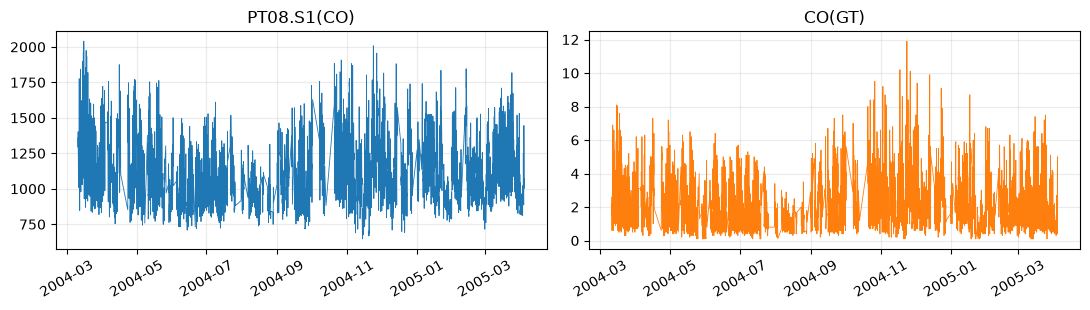

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(par.index, par[SENSOR], lw=0.6)
ax[0].set_title(SENSOR)
ax[1].plot(par.index, par[REFER], lw=0.6, color="tab:orange")
ax[1].set_title(REFER)
for a in ax:
    a.tick_params(axis="x", rotation=30)
fig.tight_layout()

## 4. Particion cronologica

Primer 30 por ciento de las horas para la calibracion nominal y la construccion del prior. El resto para el monitoreo en linea. No se aleatoriza.

**Que hace esta celda.** Divide el par en dos tramos consecutivos: el primer 30 % de las horas es el tramo de calibracion, el 70 % restante es el tramo de monitoreo. `iloc[:n_cal]` e `iloc[n_cal:]` cortan por posicion, no por sorteo.

**Por que no se aleatoriza.** En un problema secuencial la particion aleatoria seria una fuga de informacion: el modelo de calibracion "conoceria" horas del futuro. En terminos del capitulo, la previa $p(\mu)$ debe construirse con datos anteriores a los que despues se van a actualizar; de lo contrario la posterior no mide lo que dice medir. La tabla confirma que la calibracion cubre de marzo a julio de 2004 y el monitoreo de julio de 2004 a abril de 2005.

In [27]:
n_cal = int(0.30 * len(par))
cal = par.iloc[:n_cal]
mon = par.iloc[n_cal:]

pd.DataFrame({"tramo": ["calibracion", "monitoreo"],
              "n": [len(cal), len(mon)],
              "inicio": [cal.index[0], mon.index[0]],
              "fin": [cal.index[-1], mon.index[-1]]})

,tramo,n,inicio,fin
0,calibracion,2203,2004-03-10 18:00:00,2004-07-02 20:00:00
1,monitoreo,5141,2004-07-02 21:00:00,2005-04-04 14:00:00


## 5. Calibracion nominal

Recta ajustada por minimos cuadrados solo sobre el tramo de calibracion.

$$g(s) = a + b\,s, \qquad e_t = y_t - g(s_t)$$

**Que hace esta celda.** Ajusta la recta de calibracion nominal $g(s) = a + b\,s$ por minimos cuadrados, usando unicamente el tramo de calibracion, y calcula los errores $e_t = y_t - g(s_t)$ en los dos tramos.

- `ajustar_ols` construye la matriz de diseno con una columna de unos y una columna con la senal del sensor, y resuelve el sistema de minimos cuadrados con `np.linalg.lstsq`. El resultado son los coeficientes $a$ y $b$.
- `g` aplica la recta a cualquier senal.
- `e_cal` y `e_mon` son los errores en calibracion y en monitoreo con los mismos coeficientes.

**Conexion con el libro.** Aqui se decide la forma parametrica. A partir de esta celda el objeto de estudio es $e_t$, y el modelo del capitulo es $e_t \sim \mathcal{N}(\mu, \sigma^2)$ con $\mu$ desconocida. La recta es solo el paso previo que convierte la senal del sensor en la misma unidad de la referencia; el libro no la discute porque supone que la muestra ya viene en la variable de interes.

**Como leer la salida.** La media de `e_cal` es cero por construccion: minimos cuadrados garantiza que los residuos del tramo ajustado promedian cero. La media de `e_mon` es 0,163 y su desviacion 0,74, mayor que la 0,56 de calibracion. Ese 0,163 ya es una senal: en el tramo de monitoreo el sensor lee, en promedio, 0,16 mg/m3 por debajo de la referencia. Vale la pena recordarlo al llegar a la seccion 9.

In [28]:
def ajustar_ols(s, y):
    A = np.column_stack([np.ones(len(s)), s])
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)
    return coef

def g(s, coef):
    return coef[0] + coef[1] * s

coef = ajustar_ols(cal[SENSOR].to_numpy(), cal[REFER].to_numpy())

e_cal = cal[REFER].to_numpy() - g(cal[SENSOR].to_numpy(), coef)
e_mon = mon[REFER].to_numpy() - g(mon[SENSOR].to_numpy(), coef)

pd.Series({"a": coef[0], "b": coef[1],
           "media e_cal": e_cal.mean(), "sd e_cal": e_cal.std(ddof=1),
           "media e_mon": e_mon.mean(), "sd e_mon": e_mon.std(ddof=1)}).round(4)

a             -3.7990
b              0.0052
media e_cal   -0.0000
sd e_cal       0.5576
media e_mon    0.1630
sd e_mon       0.7399
dtype: float64

**Que hace esta celda.** A la izquierda, la nube de puntos sensor contra referencia en calibracion con la recta ajustada encima; permite ver si la relacion es razonablemente lineal. A la derecha, los histogramas de $e_t$ en calibracion y en monitoreo, superpuestos y normalizados. Si el modelo normal es adecuado, deberian verse campanas centradas en cero; si el de monitoreo esta desplazado o es mas ancho, el sensor cambio.

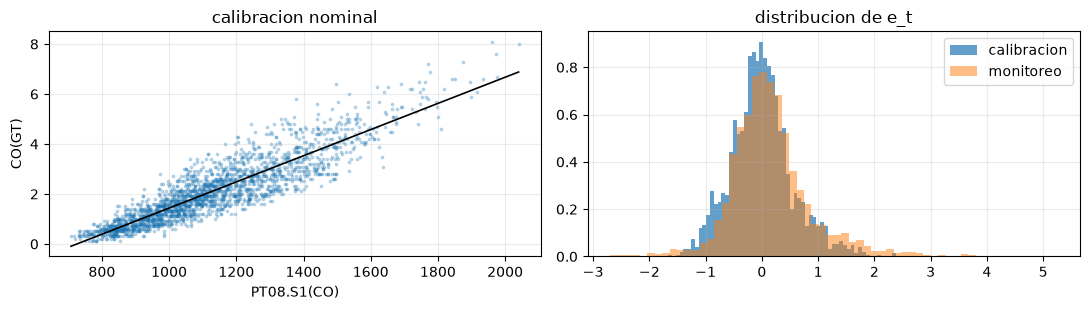

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].scatter(cal[SENSOR], cal[REFER], s=3, alpha=0.25)
rejilla = np.linspace(cal[SENSOR].min(), cal[SENSOR].max(), 100)
ax[0].plot(rejilla, g(rejilla, coef), color="black", lw=1.2)
ax[0].set_xlabel(SENSOR); ax[0].set_ylabel(REFER); ax[0].set_title("calibracion nominal")

ax[1].hist(e_cal, bins=60, density=True, alpha=0.7, label="calibracion")
ax[1].hist(e_mon, bins=60, density=True, alpha=0.5, label="monitoreo")
ax[1].set_title("distribucion de e_t"); ax[1].legend()
fig.tight_layout()

**Como leer las graficas.** A la izquierda, la nube sensor contra referencia es alargada y la recta la
atraviesa por el centro, pero con dos detalles: la dispersion crece con el nivel de CO (los puntos
se abren hacia la derecha) y la nube se curva ligeramente hacia arriba en los valores altos. La
relacion es aproximadamente lineal en el rango de trabajo habitual, entre 800 y 1400 unidades, que
es donde esta la mayoria de las horas, y la recta subestima la referencia en los episodios de mayor
concentracion. A la derecha, las dos campanas de $e_t$ estan centradas cerca de cero, pero la de
monitoreo es mas ancha y tiene una cola derecha mas larga: valores de $e_t$ entre 2 y 4 que en
calibracion casi no aparecen. Un $e_t$ positivo significa que la referencia midio mas de lo que la
recta predijo, es decir, el sensor se quedo corto. Esa cola derecha son los episodios de
contaminacion alta del invierno, y es la primera evidencia de que la hipotesis normal del capitulo
describe bien el centro de la distribucion pero no sus extremos.

## 6. Actualizacion bayesiana recursiva

$$e_t \mid \mu \sim \mathcal{N}(\mu, \sigma^2), \qquad \mu \sim \mathcal{N}(\mu_0, \sigma_0^2)$$

$$\sigma_n^2 = \left(\frac{1}{\sigma_0^2} + \frac{n}{\sigma^2}\right)^{-1}, \qquad \mu_n = \sigma_n^2\left(\frac{\mu_0}{\sigma_0^2} + \frac{1}{\sigma^2}\sum_{i=1}^{n} e_i\right)$$

$$e_{n+1} \mid D_n \sim \mathcal{N}\!\left(\mu_n,\ \sigma^2 + \sigma_n^2\right)$$

Las estadisticas suficientes son el conteo y la suma de los errores, asi que la actualizacion no requiere guardar el historico.

El parametro `olvido` multiplica ambas estadisticas en cada paso. Con `olvido = 1` se recupera el filtro bayesiano exacto. Con `olvido < 1` el conteo efectivo se satura y la posterior deja de congelarse, que es la version util para vigilar deriva.

**Que hace esta celda.** Es el corazon del cuaderno: programa la actualizacion bayesiana recursiva de la media de una normal con varianza conocida.

Primero fija los hiperparametros. `SIGMA2` es la varianza del ruido, estimada del tramo de calibracion y tratada como conocida de ahi en adelante. `MU0 = 0` dice que, antes de ver datos de monitoreo, lo mas creible es que el sensor no tenga sesgo (acaba de calibrarse). `SIGMA2_0 = SIGMA2` es la varianza de la previa: una previa con la misma dispersion que un solo dato, es decir, una previa que vale tanto como una observacion.

Luego `monitorear` recorre los errores uno por uno. En cada paso `i`:

1. Antes de ver el dato, calcula la varianza predictiva `var_pred = s2 + s2_ant` y la log densidad predictiva del dato `lp[i]`, evaluada contra la posterior del paso anterior. Esto es $\log p(e_i \mid D_{i-1})$.
2. Actualiza las estadisticas suficientes: el conteo `n_ef` y la suma `suma`. El factor `olvido` multiplica ambas antes de sumar el dato nuevo.
3. Calcula la varianza posterior `s2n[i]` y la media posterior `mu[i]` con las formulas del capitulo.

**Conexion con el libro.** Las tres formulas son exactamente las de la seccion 3.4.1. El libro escribe la media posterior como una combinacion convexa,

$$\mu_n = \frac{n\sigma_0^2}{n\sigma_0^2 + \sigma^2}\,\bar{e}_n + \frac{\sigma^2}{n\sigma_0^2 + \sigma^2}\,\mu_0,$$

y la varianza posterior como $\sigma_n^2 = \sigma_0^2\sigma^2 / (n\sigma_0^2 + \sigma^2)$. La forma que usa el codigo, $1/\sigma_n^2 = 1/\sigma_0^2 + n/\sigma^2$ y $\mu_n = \sigma_n^2(\mu_0/\sigma_0^2 + \sum e_i/\sigma^2)$, es la misma expresion reordenada: las precisiones (inversos de varianza) se suman, y la media posterior es el promedio de $\mu_0$ y de los datos ponderado por sus precisiones. Con $\sigma_0^2 = \sigma^2$ la combinacion se simplifica a $\mu_n = \frac{n}{n+1}\bar{e}_n + \frac{1}{n+1}\mu_0$, y esa fraccion es la que se vera en la tabla de la seccion 10.

La densidad predictiva `lp` es la seccion 3.4.2: $p(x \mid D) = \mathcal{N}(\mu_n, \sigma^2 + \sigma_n^2)$. La varianza predictiva suma dos incertidumbres, la del ruido y la del propio parametro.

Que baste con guardar `n_ef` y `suma` es la seccion 3.6: para la normal con varianza conocida, $(n, \sum x_i)$ es una estadistica suficiente, asi que la posterior despues de mil datos se calcula igual de bien con dos numeros que con los mil. Y que la posterior de hoy sirva de previa para manana es el aprendizaje bayesiano recursivo de la seccion 3.5, $p(\mu \mid D_n) \propto p(e_n \mid \mu)\,p(\mu \mid D_{n-1})$.

**El factor de olvido no esta en el libro.** Con `olvido = 1` se recupera la posterior exacta. Con `olvido < 1` las estadisticas suficientes se descuentan geometricamente, de modo que el conteo efectivo se satura en $1/(1 - \text{olvido})$ y la posterior nunca se "congela". Es una desviacion deliberada del modelo del capitulo, porque en el modelo exacto $\sigma_n^2 \to 0$ y la posterior deja de reaccionar a datos nuevos, que es lo contrario de lo que se necesita para vigilar un sensor que puede cambiar.

In [30]:
SIGMA2 = float(np.var(e_cal, ddof=1))
MU0 = 0.0
SIGMA2_0 = SIGMA2

def monitorear(e, mu0=MU0, s2_0=SIGMA2_0, s2=SIGMA2, olvido=1.0):
    n = len(e)
    mu = np.empty(n)
    s2n = np.empty(n)
    lp = np.empty(n)
    n_ef = 0.0
    suma = 0.0
    mu_ant, s2_ant = mu0, s2_0
    for i in range(n):
        var_pred = s2 + s2_ant
        lp[i] = -0.5 * (np.log(2 * np.pi * var_pred) + (e[i] - mu_ant) ** 2 / var_pred)
        n_ef = olvido * n_ef + 1.0
        suma = olvido * suma + e[i]
        s2n[i] = 1.0 / (1.0 / s2_0 + n_ef / s2)
        mu[i] = s2n[i] * (mu0 / s2_0 + suma / s2)
        mu_ant, s2_ant = mu[i], s2n[i]
    return pd.DataFrame({"e": e, "mu": mu, "s2n": s2n, "lp": lp})

pd.Series({"sigma2": SIGMA2, "sigma": np.sqrt(SIGMA2),
           "mu0": MU0, "sigma2_0": SIGMA2_0}).round(4)

sigma2      0.3109
sigma       0.5576
mu0         0.0000
sigma2_0    0.3109
dtype: float64

**Que hace esta celda.** Corre el monitoreo dos veces sobre el tramo de monitoreo, una con la posterior exacta (`olvido = 1`) y otra con descuento (`olvido = 0.995`), y compara la media y la desviacion posterior a las 100 horas y al final de las 5141 horas.

In [31]:
exacto = monitorear(e_mon, olvido=1.0)
ventana = monitorear(e_mon, olvido=0.995)

pd.DataFrame({
    "olvido 1.000": [exacto["mu"].iloc[99], np.sqrt(exacto["s2n"].iloc[99]),
                     exacto["mu"].iloc[-1], np.sqrt(exacto["s2n"].iloc[-1])],
    "olvido 0.995": [ventana["mu"].iloc[99], np.sqrt(ventana["s2n"].iloc[99]),
                     ventana["mu"].iloc[-1], np.sqrt(ventana["s2n"].iloc[-1])],
}, index=["mu tras 100", "sd tras 100", "mu final", "sd final"]).round(4)

,olvido 1.000,olvido 0.995
mu tras 100,0.1138,0.1462
sd tras 100,0.0555,0.0624
mu final,0.1630,-0.1749
sd final,0.0078,0.0393


**Como leer la salida.** A las 100 horas las dos versiones casi coinciden (0,114 frente a 0,146), porque con pocos datos el descuento apenas ha actuado. Al final se separan: la posterior exacta termina en 0,163, que es justamente la media de todos los errores de monitoreo (con $n = 5141$ la previa ya no pesa nada), con una desviacion posterior de 0,008, es decir, casi una certeza. La version con olvido termina en $-0,175$ con desviacion 0,039: describe el sesgo de las ultimas doscientas horas, no el promedio de todo el tramo, y conserva incertidumbre. La posterior exacta responde "cual fue el sesgo medio del sensor en estos nueve meses"; la version con olvido responde "cual es el sesgo del sensor ahora". Para recalibrar interesa la segunda pregunta.

**Que hace esta celda.** Calcula cuanto vale el conteo efectivo maximo con `olvido = 0.995`, que es $1/(1 - 0{,}995) = 200$ horas, y la desviacion posterior a la que converge con ese conteo, usando la misma formula $\sigma_n^2 = (1/\sigma_0^2 + n/\sigma^2)^{-1}$ con $n = 200$. La compara con la desviacion final de la version exacta.

**Como leer la salida.** La desviacion asintotica de 0,039 coincide con la "sd final" de la celda anterior: la version con olvido se comporta como una posterior exacta que solo hubiera visto las ultimas 200 horas. Es la manera de traducir el parametro `olvido` a algo interpretable: una ventana efectiva de memoria.

In [32]:
n_ef_saturado = 1.0 / (1.0 - 0.995)
pd.Series({"conteo efectivo maximo con olvido 0.995": n_ef_saturado,
           "sd posterior asintotica": np.sqrt(1.0 / (1.0 / SIGMA2_0 + n_ef_saturado / SIGMA2)),
           "sd posterior con olvido 1 al final": np.sqrt(exacto["s2n"].iloc[-1])}).round(4)

conteo efectivo maximo con olvido 0.995    200.0000
sd posterior asintotica                      0.0393
sd posterior con olvido 1 al final           0.0078
dtype: float64

**Que hace esta celda.** Dibuja $\mu_n$ a lo largo del tiempo para las dos versiones, con una banda de mas o menos dos desviaciones posteriores. La linea negra en cero es el sesgo que tendria un sensor perfectamente calibrado.

**Como leer la grafica.** La banda azul (posterior exacta) se estrecha hasta volverse una linea, que es lo que el capitulo llama aprendizaje bayesiano: $p(\mu \mid D_n)$ se concentra cada vez mas alrededor de un valor (seccion 3.4.1, figura de las posteriores que se afilan con $n$). La banda roja mantiene un ancho constante y sigue las oscilaciones del sesgo. Si el sensor fuera estable, las dos lineas se superpondrian; que la roja se aleje de la azul es evidencia de que el sesgo cambia con el tiempo.

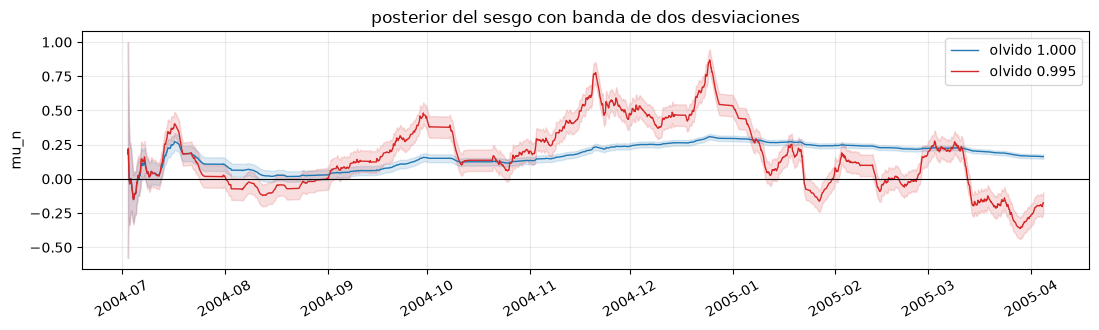

In [33]:
t = mon.index
fig, ax = plt.subplots(figsize=(11, 3.4))
for res, etiqueta, color in [(exacto, "olvido 1.000", "tab:blue"),
                             (ventana, "olvido 0.995", "tab:red")]:
    m = res["mu"].to_numpy()
    s = np.sqrt(res["s2n"].to_numpy())
    ax.plot(t, m, lw=1.0, color=color, label=etiqueta)
    ax.fill_between(t, m - 2 * s, m + 2 * s, color=color, alpha=0.15)
ax.axhline(0.0, color="black", lw=0.8)
ax.set_ylabel("mu_n"); ax.set_title("posterior del sesgo con banda de dos desviaciones")
ax.legend(); ax.tick_params(axis="x", rotation=30)
fig.tight_layout()

**Lo que muestra la grafica.** La linea azul, posterior exacta, sube lentamente desde cero hasta
estabilizarse alrededor de 0,2 y luego baja despacio a 0,16; su banda es tan estrecha que casi no se
ve. La linea roja, con olvido, cuenta otra historia: el sesgo oscila entre $-0{,}2$ y $0{,}9$, con
dos picos claros en octubre y en diciembre de 2004, un valle en enero y otro descenso en marzo de
2005. El sesgo del sensor no es una constante, se mueve con la estacion. Esto es tipico de los
sensores de oxido metalico, cuya respuesta depende de la temperatura y la humedad, y encaja con el
hecho de que los picos coinciden con los meses de mayor contaminacion.

En terminos del capitulo, el modelo $e_t \sim \mathcal{N}(\mu, \sigma^2)$ con $\mu$ fijo es el que
la posterior exacta esta estimando, y lo estima bien: 0,16 es el promedio del periodo. Pero la
grafica roja dice que ese modelo es incompleto, porque $\mu$ cambia. La posterior exacta converge a
un promedio de sesgos que en ningun mes concreto es el sesgo real; la version con olvido renuncia a
la convergencia a cambio de seguir el valor actual. Es una ilustracion concreta de la advertencia de
la seccion 3.1: los resultados del capitulo suponen que los datos son i.i.d. de una distribucion que
no cambia, y cuando eso falla la posterior sigue siendo matematicamente correcta pero responde a la
pregunta equivocada.

## 7. Alerta probabilistica

Umbral fijado en el percentil 1 de la log densidad predictiva calculada sobre el tramo de calibracion. Cada observacion se evalua contra la predictiva construida antes de verla.

**Que hace esta celda.** Construye la regla de alerta. Primero corre el monitoreo sobre el tramo de calibracion (`base`) para obtener la distribucion de la log densidad predictiva en condiciones normales, y fija el umbral en su percentil 1: por definicion, en calibracion solo el 1 % de las horas cae por debajo. Luego marca como alerta cada hora de monitoreo cuya `lp` (calculada por `monitorear` antes de incorporar el dato) queda por debajo del umbral.

**Conexion con el libro.** La alerta usa la densidad predictiva $p(e_t \mid D_{t-1})$ de la seccion 3.4.2 como medida de sorpresa: un dato es anomalo si el modelo, con lo que sabia hasta la hora anterior, lo consideraba muy improbable. Es la misma cantidad que en clasificacion se usaria como $p(x \mid D_i)$ en la regla de Bayes (seccion 3.3), solo que aqui hay una unica clase y se pregunta si el dato pertenece a ella.

In [34]:
base = monitorear(e_cal, olvido=1.0)
UMBRAL_LP = float(np.quantile(base["lp"], 0.01))

alerta = (exacto["lp"] < UMBRAL_LP).to_numpy()

pd.Series({"umbral log predictiva": UMBRAL_LP,
           "alertas en monitoreo": int(alerta.sum()),
           "tasa de alerta": float(alerta.mean()),
           "tasa esperada bajo el nulo": 0.01}).round(4)

umbral log predictiva          -4.9098
alertas en monitoreo          213.0000
tasa de alerta                  0.0414
tasa esperada bajo el nulo      0.0100
dtype: float64

**Como leer la salida.** En monitoreo saltan 213 alertas, el 4,1 % de las horas, cuando bajo el modelo se esperaba 1 %. Hay dos lecturas compatibles: el tramo de monitoreo tiene episodios reales de contaminacion que la referencia mide y el sensor subestima, o el ruido del sensor en monitoreo es mayor que en calibracion (la desviacion de $e_t$ subio de 0,56 a 0,74 en la seccion 5, y $\sigma^2$ se dejo fijo en el valor de calibracion). La seccion 8 mide directamente esa segunda explicacion.

**Que hace esta celda.** Dibuja la log densidad predictiva hora a hora, el umbral en rojo y las horas marcadas como alerta como puntos rojos. Si las alertas se agrupan en episodios de varias horas seguidas, son mas compatibles con eventos ambientales; si aparecen aisladas, con ruido del instrumento.

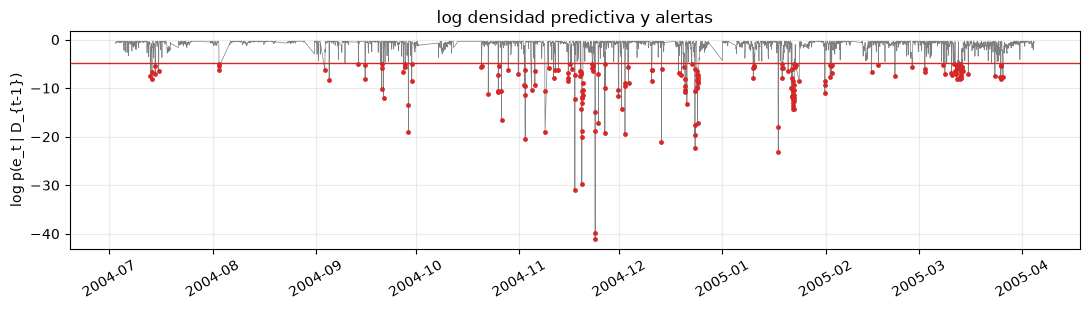

In [35]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(t, exacto["lp"], lw=0.5, color="tab:gray")
ax.axhline(UMBRAL_LP, color="tab:red", lw=1.0)
ax.scatter(t[alerta], exacto["lp"].to_numpy()[alerta], s=6, color="tab:red", zorder=3)
ax.set_ylabel("log p(e_t | D_{t-1})"); ax.set_title("log densidad predictiva y alertas")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()

**Lo que muestra la grafica.** Las alertas no estan repartidas de manera uniforme: se concentran
entre octubre y diciembre de 2004 y vuelven a aparecer en enero y marzo de 2005, en grupos de varias
horas seguidas, y practicamente no hay ninguna entre julio y septiembre. Los valores mas extremos,
con log densidad predictiva por debajo de $-20$ y hasta $-40$, estan a mediados de noviembre. Una
log densidad de $-40$ corresponde a un error a mas de ocho desviaciones de lo esperado, algo que
bajo el modelo normal no deberia ocurrir nunca en 5000 horas. Que ocurra, y que ocurra en grupos y
en los meses frios, apunta a episodios reales de contaminacion en los que la referencia sube y el
sensor no la sigue, mas que a fallos aislados del instrumento. Es la lectura que la seccion 14
convierte en limitacion: la predictiva mide sorpresa estadistica, no distingue su causa.

## 8. Cobertura de los intervalos predictivos

Fraccion de observaciones que cae dentro del intervalo predictivo nominal. Es la verificacion de que la incertidumbre reportada no esta subestimada.

**Que hace esta celda.** Verifica la calibracion de la incertidumbre. Para cada hora construye el intervalo predictivo $\mu_{t-1} \pm z\sqrt{\sigma^2 + \sigma_{t-1}^2}$ con $z = 1{,}645$ (90 %) y $z = 1{,}96$ (95 %) y cuenta que fraccion de los errores observados cae dentro. Si el modelo dice la verdad sobre su propia incertidumbre, esa fraccion deberia ser 0,90 y 0,95.

**Conexion con el libro.** Es una comprobacion empirica de la predictiva de la seccion 3.4.2. El capitulo demuestra que $p(x \mid D)$ es normal con varianza $\sigma^2 + \sigma_n^2$; esta celda pregunta si esa varianza describe bien los datos que llegan.

In [36]:
def cobertura(res, s2=SIGMA2):
    sd = np.sqrt(s2 + res["s2n"].to_numpy())
    mu = res["mu"].to_numpy()
    e = res["e"].to_numpy()
    filas = {}
    for nivel, z in [(0.90, 1.6449), (0.95, 1.9600)]:
        dentro = np.abs(e - mu) <= z * sd
        filas[f"nominal {nivel:.2f}"] = dentro.mean()
    return pd.Series(filas)

pd.DataFrame({"olvido 1.000": cobertura(exacto),
              "olvido 0.995": cobertura(ventana)}).round(4)

,olvido 1.000,olvido 0.995
nominal 0.90,0.8465,0.8572
nominal 0.95,0.8885,0.8963


**Como leer la salida.** La cobertura queda por debajo de la nominal en los dos casos: 0,85 en lugar de 0,90 y 0,89 en lugar de 0,95. Los intervalos son demasiado estrechos, y la causa es la hipotesis de $\sigma^2$ conocida: se fijo con la desviacion de calibracion (0,56) y en monitoreo la dispersion real es mayor (0,74). El capitulo trabaja con $\sigma^2$ conocida por simplicidad (seccion 3.4.1) y remite el caso general de media y varianza desconocidas a la teoria de la seccion 3.5; el diagnostico de la seccion 13 retoma este punto.

## 9. Deteccion de deriva sobre una rampa artificial

Se inyecta una rampa lineal en la segunda mitad del tramo de monitoreo, de pendiente igual a dos desviaciones de ruido a lo largo del tramo. Se declara deriva cuando la posterior se aleja del cero mas de `k` desviaciones posteriores durante `persistencia` horas seguidas, para no disparar por un unico dato extremo.

**Que hace esta celda.** Monta un experimento controlado de deteccion de deriva.

- `inyectar_rampa` toma los errores reales de monitoreo y, a partir de la mitad del tramo, les suma una rampa lineal que crece de cero hasta dos desviaciones de ruido. Simula un sensor que empieza a desajustarse lentamente.
- `declarar_deriva` recorre la posterior y declara deriva en la primera hora en que $|\mu_t| > k\,\sigma_t$ se ha cumplido durante `persistencia` horas consecutivas (por defecto $k = 3$ y 24 horas). La persistencia evita disparar por un unico dato extremo.
- El bucle prueba cuatro valores de olvido y, para cada uno, mide si hay falsa alarma antes de la rampa y cuantas horas tarda en detectarla.

**Conexion con el libro.** La regla compara la media posterior con su propia desviacion, es decir, usa la posterior completa $p(\mu \mid D)$ y no solo un estimador puntual. Es el argumento central de la seccion 3.3: la estimacion bayesiana conserva la incertidumbre del parametro, y esa incertidumbre es lo que permite decir si un desplazamiento de $\mu_n$ es significativo o es ruido.

In [37]:
def inyectar_rampa(e, inicio_frac=0.5, magnitud=2.0, s2=SIGMA2):
    e2 = e.copy()
    i0 = int(inicio_frac * len(e))
    rampa = np.zeros(len(e))
    rampa[i0:] = np.linspace(0.0, magnitud * np.sqrt(s2), len(e) - i0)
    return e2 + rampa, i0

def declarar_deriva(res, k=3.0, persistencia=24):
    fuera = np.abs(res["mu"].to_numpy()) > k * np.sqrt(res["s2n"].to_numpy())
    corrida = 0
    for i, f in enumerate(fuera):
        corrida = corrida + 1 if f else 0
        if corrida >= persistencia:
            return i
    return None

e_drift, i0 = inyectar_rampa(e_mon)

filas = []
for olv in [1.0, 0.999, 0.995, 0.99]:
    limpio = monitorear(e_mon, olvido=olv)
    sucio = monitorear(e_drift, olvido=olv)
    i_falso = declarar_deriva(limpio)
    i_det = declarar_deriva(sucio)
    filas.append({
        "olvido": olv,
        "falsa alarma antes de la rampa": (i_falso is not None and i_falso < i0),
        "horas hasta detectar": None if i_det is None or i_det < i0 else i_det - i0,
        "sesgo real al detectar": None if i_det is None or i_det < i0 else round(float(e_drift[i_det] - e_mon[i_det]), 3),
    })

pd.DataFrame(filas)

,olvido,falsa alarma antes de la rampa,horas hasta detectar,sesgo real al detectar
0,1.000,True,None,None
1,0.999,True,None,None
2,0.995,True,None,None
3,0.990,True,None,None


**Como leer la salida, y por que no dice lo que uno esperaria.** Las cuatro filas marcan falsa alarma antes de la rampa y ninguna deteccion. No es un fallo del codigo sino una consecuencia de un dato de la seccion 5: en el tramo de monitoreo el sesgo real del sensor ya es 0,163 desde el principio. Con miles de horas, la desviacion posterior baja a centesimas, y $|\mu_t| = 0{,}16$ supera con holgura $3\sigma_t$ mucho antes de que empiece la rampa. La regla detecta correctamente que el sensor esta sesgado respecto de su calibracion, pero lo hace desde el inicio, y por eso la funcion devuelve una hora anterior a `i0` y el experimento la cuenta como falsa alarma; una vez disparada, ya no hay "primera deteccion" despues de la rampa.

La leccion es la del capitulo, no un tecnicismo: la previa $\mu_0 = 0$ afirma que el sensor sale de calibracion sin sesgo, y los datos la contradicen. Dos maneras de arreglar el experimento son declarar deriva respecto del sesgo estimado en las primeras semanas de monitoreo (recentrar la previa) o vigilar cambios de $\mu_t$ entre ventanas consecutivas en lugar de su distancia al cero. Ambas son variantes de la misma maquinaria bayesiana con otra previa.

**Que hace esta celda.** Dibuja la posterior con rampa (roja, banda de tres desviaciones) sobre la posterior sin rampa (azul), la hora en que empieza la rampa (linea negra discontinua) y, si la hubiera, la hora en que se declara deriva (verde). Como la deteccion se dispara antes de `i0`, la linea verde queda a la izquierda de la negra, que es la forma visual de la observacion anterior.

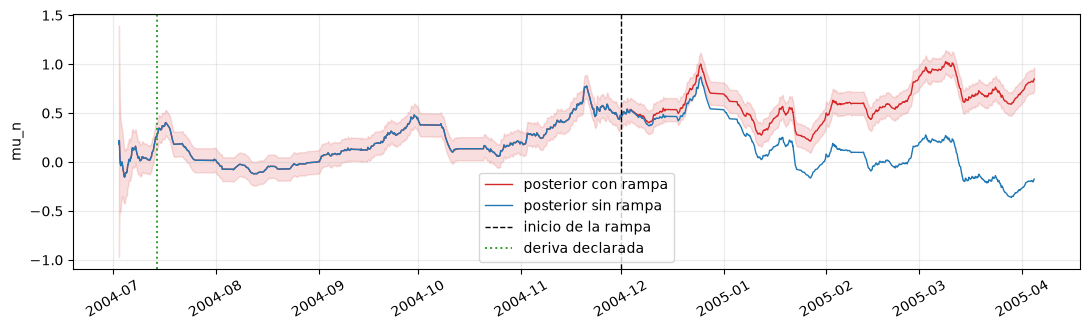

In [38]:
res_drift = monitorear(e_drift, olvido=0.995)
i_det = declarar_deriva(res_drift)

fig, ax = plt.subplots(figsize=(11, 3.4))
m = res_drift["mu"].to_numpy()
s = np.sqrt(res_drift["s2n"].to_numpy())
ax.plot(t, m, lw=1.0, color="tab:red", label="posterior con rampa")
ax.fill_between(t, m - 3 * s, m + 3 * s, color="tab:red", alpha=0.15)
ax.plot(t, ventana["mu"], lw=1.0, color="tab:blue", label="posterior sin rampa")
ax.axvline(t[i0], color="black", ls="--", lw=1.0, label="inicio de la rampa")
if i_det is not None:
    ax.axvline(t[i_det], color="tab:green", ls=":", lw=1.4, label="deriva declarada")
ax.legend(); ax.set_ylabel("mu_n"); ax.tick_params(axis="x", rotation=30)
fig.tight_layout()

**Lo que muestra la grafica.** La linea verde de "deriva declarada" aparece a mediados de julio de
2004, cuatro meses antes de la linea negra que marca el inicio de la rampa. Es la deteccion
prematura explicada arriba: a esa altura la posterior ya esta por encima de 0,3 con una banda
estrecha, y la regla la lee como sesgo significativo. Despues del inicio de la rampa las dos curvas
se separan como deberian, la roja termina cerca de 0,9 y la azul cerca de $-0{,}2$, y esa separacion
creciente es la deriva inyectada. El filtro la sigue correctamente; lo que fallo fue el criterio de
alarma, que comparaba con cero cuando el sesgo real de partida no era cero.

## 10. Maxima verosimilitud frente a Bayes en muestra pequena

Se compara el estimador puntual de maxima verosimilitud, que es la media de los errores observados, contra la media posterior, sobre los primeros `n` datos. La diferencia se hace visible solo cuando `n` es pequeno.

**Que hace esta celda.** Para $n$ creciente, compara el estimador de maxima verosimilitud de $\mu$, que para la normal es la media muestral $\bar{e}_n$, contra la media posterior $\mu_n$ obtenida con la previa $\mathcal{N}(0, \sigma^2)$. La columna `contraccion` es la diferencia entre los dos.

**Conexion con el libro.** Es la comparacion de las secciones 3.2.2 y 3.5.1. El MLE de la media de una normal es $\hat{\mu} = \frac{1}{n}\sum x_k$ (ecuacion de la seccion 3.2.2). La media posterior es la combinacion convexa $\mu_n = \frac{n\sigma_0^2}{n\sigma_0^2+\sigma^2}\bar{e}_n + \frac{\sigma^2}{n\sigma_0^2+\sigma^2}\mu_0$, que con $\sigma_0^2 = \sigma^2$ y $\mu_0 = 0$ se reduce a $\mu_n = \frac{n}{n+1}\bar{e}_n$. La seccion 3.5.1 explica cuando difieren: cuando la muestra es pequena o la previa es informativa; cuando $n$ crece, la posterior se concentra en el MLE.

In [39]:
filas = []
for n in [1, 2, 5, 10, 25, 50, 100, 250, 500, 1000]:
    sub = e_mon[:n]
    mle = float(np.mean(sub))
    res = monitorear(sub, olvido=1.0)
    filas.append({"n": n, "mle": mle,
                  "media posterior": float(res["mu"].iloc[-1]),
                  "sd posterior": float(np.sqrt(res["s2n"].iloc[-1])),
                  "contraccion": float(mle - res["mu"].iloc[-1])})

pd.DataFrame(filas).round(4)

,n,mle,media posterior,sd posterior,contraccion
0,1,0.4215,0.2107,0.3943,0.2107
1,2,0.3068,0.2046,0.3219,0.1023
2,5,0.2025,0.1688,0.2276,0.0338
3,10,0.0009,0.0008,0.1681,0.0001
4,25,-0.0210,-0.0202,0.1094,-0.0008
5,50,-0.1110,-0.1088,0.0781,-0.0022
6,100,0.1150,0.1138,0.0555,0.0011
7,250,0.1091,0.1087,0.0352,0.0004
8,500,0.1060,0.1058,0.0249,0.0002
9,1000,0.0426,0.0426,0.0176,0.0000


**Como leer la salida.** Con $n = 1$ la media posterior es exactamente la mitad del MLE (0,2107 frente a 0,4215): la previa vale como un dato, y el promedio de un dato y un cero es la mitad. Con $n = 2$ es dos tercios, con $n = 5$ cinco sextos. A partir de $n = 100$ la diferencia esta en la cuarta cifra decimal y con $n = 1000$ es cero a cuatro decimales. La columna de desviacion posterior muestra el otro lado: con $n = 1$ vale 0,39, casi el ruido completo, y baja como $1/\sqrt{n}$. El MLE nunca reporta esa incertidumbre; la posterior si.

## 11. Version multivariante con EM

Los cinco sensores se modelan de forma conjunta como una normal multivariante. EM estima la media y la covarianza usando todas las filas, incluidas las que tienen entradas faltantes, en lugar de descartarlas.

Paso E: la esperanza condicional de las entradas faltantes dada la parte observada, mas la covarianza condicional que se acumula en la matriz de correccion.

Paso M: media y covarianza muestrales sobre los datos completados, sumando la correccion.

**Que hace esta celda.** Prepara la matriz `M` con las cinco respuestas de sensor en todas las horas, incluyendo las que tienen faltantes, y cuenta filas completas, filas con algun faltante y entradas faltantes en total.

**Como leer la salida.** Hay 366 filas con algun faltante y 1830 entradas faltantes. Como $366 \times 5 = 1830$, cada fila incompleta tiene los cinco sensores en blanco a la vez: el faltante es de la fila entera, no de sensores sueltos. Conviene tener este numero presente para leer el resultado del EM.

In [40]:
SENSORES = ["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)", "PT08.S4(NO2)", "PT08.S5(O3)"]
M = df[SENSORES].to_numpy(dtype=float)

pd.Series({"filas": M.shape[0],
           "filas completas": int((~np.isnan(M)).all(axis=1).sum()),
           "filas con algun faltante": int(np.isnan(M).any(axis=1).sum()),
           "entradas faltantes": int(np.isnan(M).sum())})

filas                       9357
filas completas             8991
filas con algun faltante     366
entradas faltantes          1830
dtype: int64

**Que hace esta celda.** Implementa EM para estimar la media $\mu$ y la covarianza $\Sigma$ de una normal multivariante cuando algunas entradas de algunas filas faltan.

Inicializa `mu` con las medias por columna ignorando faltantes y `Sig` con una diagonal de varianzas. Luego itera:

*Paso E.* Para cada fila `i`, `o` marca las entradas observadas y `m` las faltantes. Si no falta nada, no hay que hacer nada. Si falta todo, la mejor conjetura es la media y la incertidumbre es toda la covarianza. En el caso intermedio se usa la formula de la normal condicional: la esperanza de la parte faltante dada la observada es $\mu_m + \Sigma_{mo}\Sigma_{oo}^{-1}(x_o - \mu_o)$ (eso es `Xh[i, m]`), y la covarianza condicional $\Sigma_{mm} - \Sigma_{mo}\Sigma_{oo}^{-1}\Sigma_{om}$ se acumula en `Corr`. `np.linalg.solve` resuelve el sistema en lugar de invertir $\Sigma_{oo}$, que es mas estable. `ridge` suma una cantidad minuscula a la diagonal para que el sistema nunca sea singular.

*Paso M.* Con los datos completados `Xh`, la media es la media muestral y la covarianza es la covarianza muestral mas la correccion `Corr / n`. Sin esa correccion se estaria tratando los valores imputados como si fueran observaciones exactas y la covarianza quedaria subestimada.

*Parada.* Se detiene cuando el cambio relativo maximo en `mu` y en `Sig` baja de `tol`.

**Conexion con el libro.** Es la seccion 3.9. El capitulo define la funcion $Q(\theta; \theta^i) = E_{D_b}[\ln p(D_g, D_b \mid \theta) \mid D_g; \theta^i]$, donde $D_g$ son los datos "buenos" (observados) y $D_b$ los "malos" (faltantes), y alterna entre calcular esa esperanza (paso E) y maximizarla (paso M). Para la normal, la esperanza de la log verosimilitud completa solo depende de las estadisticas suficientes $\sum x$ y $\sum x x^\top$, asi que el paso E se reduce a calcular la esperanza condicional de los faltantes y de sus productos cruzados, que es exactamente lo que hacen `Xh` y `Corr`. El ejemplo 2 de la seccion 3.9 hace este mismo calculo a mano para una normal bidimensional con una coordenada faltante; esta funcion es su version general en $d$ dimensiones. El libro tambien demuestra que cada iteracion no disminuye la verosimilitud, que es lo que se comprueba en la grafica de convergencia.

In [41]:
def em_normal_multivariante(X, iteraciones=200, tol=1e-7, ridge=1e-8):
    X = np.asarray(X, dtype=float)
    n, d = X.shape
    obs = ~np.isnan(X)
    mu = np.nanmean(X, axis=0)
    Sig = np.diag(np.nanvar(X, axis=0, ddof=1))
    historia = []
    for it in range(iteraciones):
        Xh = X.copy()
        Corr = np.zeros((d, d))
        for i in range(n):
            o = obs[i]
            m = ~o
            if not m.any():
                continue
            if not o.any():
                Xh[i, :] = mu
                Corr += Sig
                continue
            Soo = Sig[np.ix_(o, o)] + ridge * np.eye(o.sum())
            Smo = Sig[np.ix_(m, o)]
            Xh[i, m] = mu[m] + Smo @ np.linalg.solve(Soo, X[i, o] - mu[o])
            Corr[np.ix_(m, m)] += Sig[np.ix_(m, m)] - Smo @ np.linalg.solve(Soo, Smo.T)
        mu_nuevo = Xh.mean(axis=0)
        D = Xh - mu_nuevo
        Sig_nuevo = (D.T @ D + Corr) / n
        cambio = max(float(np.max(np.abs(mu_nuevo - mu) / (np.abs(mu) + 1.0))),
                     float(np.max(np.abs(Sig_nuevo - Sig) / (np.abs(Sig) + 1.0))))
        mu, Sig = mu_nuevo, Sig_nuevo
        historia.append(cambio)
        if cambio < tol:
            break
    return mu, Sig, historia

mu_em, Sig_em, hist = em_normal_multivariante(M)
len(hist), hist[-1]

(6, 8.798103200246834e-08)

**Como leer la salida.** EM converge en 6 iteraciones con un cambio relativo final de $9 \times 10^{-8}$. Es rapido porque, como se vera en la tabla siguiente, en este conjunto casi no hay nada que aprender de las filas incompletas.

**Que hace esta celda.** Compara las estimaciones de EM contra las que se obtienen descartando las filas con algun faltante (*listwise deletion*), que es la alternativa ingenua.

In [42]:
completas = M[(~np.isnan(M)).all(axis=1)]
mu_lw = completas.mean(axis=0)
Sig_lw = np.cov(completas, rowvar=False, ddof=1)

comparacion = pd.DataFrame({
    "media EM": mu_em,
    "media descartando filas": mu_lw,
    "diferencia": mu_em - mu_lw,
    "sd EM": np.sqrt(np.diag(Sig_em)),
    "sd descartando filas": np.sqrt(np.diag(Sig_lw)),
}, index=SENSORES)
comparacion.round(3)

,media EM,media descartando filas,diferencia,sd EM,sd descartando filas
PT08.S1(CO),1099.833,1099.833,0.0,217.068,217.080
PT08.S2(NMHC),939.153,939.153,-0.0,266.817,266.831
PT08.S3(NOx),835.494,835.494,0.0,256.803,256.817
PT08.S4(NO2),1456.265,1456.265,0.0,346.188,346.207
PT08.S5(O3),1022.906,1022.906,0.0,398.462,398.484


**Como leer la salida.** Las medias coinciden exactamente y las desviaciones difieren en la tercera cifra. No es una decepcion del metodo sino una consecuencia de la estructura del faltante vista en la celda de arriba: las 366 filas incompletas tienen los cinco sensores en blanco. Una fila sin ninguna entrada observada no aporta informacion sobre $\mu$ (el paso E la rellena con $\mu$ y no mueve la media), y sobre $\Sigma$ solo aporta la propia $\Sigma$ (la correccion `Corr`), que se cancela en el paso M. EM demuestra su ventaja cuando el faltante es parcial, por ejemplo cuando un sensor falla y los otros cuatro siguen midiendo, porque entonces la parte observada informa sobre la faltante a traves de la correlacion. Aqui el metodo funciona, pero el dato no le da donde trabajar.

**Que hace esta celda.** Convierte las dos covarianzas en matrices de correlacion (dividiendo cada entrada por el producto de las desviaciones) y las dibuja junto con su diferencia. Con los datos de este conjunto la diferencia es casi cero, por la razon explicada arriba.

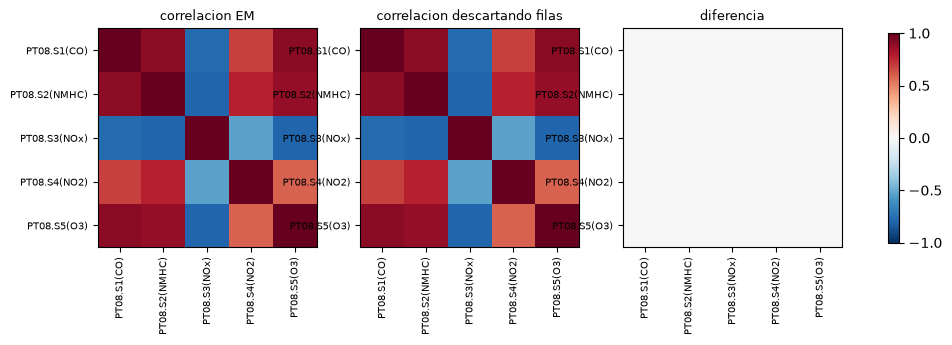

In [43]:
corr_em = Sig_em / np.outer(np.sqrt(np.diag(Sig_em)), np.sqrt(np.diag(Sig_em)))
corr_lw = Sig_lw / np.outer(np.sqrt(np.diag(Sig_lw)), np.sqrt(np.diag(Sig_lw)))

fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
for a, mat, titulo in [(ax[0], corr_em, "correlacion EM"),
                       (ax[1], corr_lw, "correlacion descartando filas"),
                       (ax[2], corr_em - corr_lw, "diferencia")]:
    im = a.imshow(mat, vmin=-1, vmax=1, cmap="RdBu_r")
    a.set_xticks(range(len(SENSORES))); a.set_xticklabels(SENSORES, rotation=90, fontsize=7)
    a.set_yticks(range(len(SENSORES))); a.set_yticklabels(SENSORES, fontsize=7)
    a.set_title(titulo, fontsize=9)
    a.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8)

**Que hace esta celda.** Dibuja, en escala logaritmica, el cambio maximo de los parametros en cada iteracion de EM. Un descenso monotono hacia cero es la firma de que EM esta convergiendo, consistente con la garantia de la seccion 3.9 de que la verosimilitud no baja de una iteracion a la siguiente.

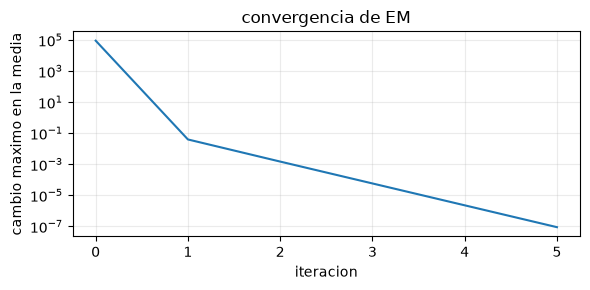

In [44]:
fig, ax = plt.subplots(figsize=(6, 3.0))
ax.semilogy(hist)
ax.set_xlabel("iteracion"); ax.set_ylabel("cambio maximo en la media")
ax.set_title("convergencia de EM")
fig.tight_layout()

## 12. Tabla de evaluacion

**Que hace esta celda.** Resume el efecto de la actualizacion. `corregido` es el error de monitoreo despues de restarle el sesgo estimado por la posterior con olvido, es decir, lo que quedaria si el sensor se recalibrara en linea con $\mu_t$. Para el error original y el corregido calcula el sesgo medio, el error absoluto medio (EAM) y la raiz del error cuadratico medio (RECM), y agrega la cobertura al 90 % y el conteo de alertas.

In [45]:
def error_calibracion(e):
    return {"sesgo": float(np.mean(e)),
            "eam": float(np.mean(np.abs(e))),
            "recm": float(np.sqrt(np.mean(e ** 2)))}

corregido = e_mon - ventana["mu"].to_numpy()

evaluacion = pd.DataFrame({
    "antes de la actualizacion": error_calibracion(e_mon),
    "despues de la actualizacion": error_calibracion(corregido),
}).T

evaluacion["cobertura 0.90"] = [cobertura(ventana)["nominal 0.90"]] * 2
evaluacion["alertas"] = [int(alerta.sum())] * 2
evaluacion.round(4)

,sesgo,eam,recm,cobertura 0.90,alertas
antes de la actualizacion,0.1630,0.5186,0.7576,0.8572,213
despues de la actualizacion,-0.0085,0.4864,0.6935,0.8572,213


**Como leer la salida.** El sesgo pasa de 0,163 a $-0{,}009$: la recalibracion en linea elimina casi todo el desplazamiento sistematico. El EAM baja de 0,52 a 0,49 y la RECM de 0,76 a 0,69; la mejora es moderada porque la mayor parte del error es ruido hora a hora, no sesgo, y el ruido no se corrige estimando $\mu$. Es una ilustracion de lo que el capitulo llama la diferencia entre sesgo y varianza del estimador (seccion 3.7.3): la actualizacion bayesiana quita el sesgo, la varianza del ruido queda.

## 13. Diagnostico de supuestos

El capitulo 3 obtiene sus resultados bajo cuatro hipotesis, y este cuaderno permite comprobar cada
una contra los datos. Ninguna se cumple del todo, y saber cuales fallan y cuanto es parte del
resultado.

**Normalidad de $e_t$.** Los histogramas de la seccion 5 y el grafico cuantil cuantil de la celda
siguiente muestran un centro razonablemente normal, pero colas distintas: la derecha es mucho mas
pesada que la de una normal (errores de 3 a 5 unidades cuando la normal predice un maximo de unas
2,5) y la izquierda es mas corta. Consecuencia: la densidad predictiva normal asigna a los episodios
de contaminacion probabilidades minusculas, y por eso la tasa de alerta de la seccion 7 es cuatro
veces la nominal. La familia parametrica correcta tendria colas mas pesadas o seria asimetrica.

**Independencia de $e_t$.** La autocorrelacion de la celda siguiente es 0,82 a una hora de rezago,
decae lentamente y vuelve a subir a 24 y 48 horas: los errores tienen memoria y un ciclo diario. Las
$n$ observaciones no son i.i.d., asi que contienen menos informacion que $n$ observaciones
independientes, y la posterior exacta se estrecha mas rapido de lo que corresponde. La desviacion
posterior de 0,008 de la seccion 6 es, por esta razon, demasiado optimista.

**Varianza $\sigma^2$ conocida y constante.** Se estimo en calibracion (0,56) y en monitoreo la
dispersion real es 0,74. Esa diferencia es la causa directa de la cobertura insuficiente de la
seccion 8. El capitulo trata $\sigma^2$ como conocida en la seccion 3.4 por simplicidad; la
extension natural, que la seccion 3.5 deja planteada en su teoria general, es una previa conjunta
sobre media y varianza (normal-gamma inversa) que actualice las dos.

**Estacionariedad del sesgo.** Es la hipotesis que mas claramente falla, como muestra la posterior
con olvido de la seccion 6: el sesgo oscila con la estacion. El modelo del capitulo estima una
$\mu$ fija; el sensor tiene una $\mu_t$ que cambia. El factor de olvido es un remedio practico, y
un modelo de espacio de estados en el que $\mu_t$ evoluciona como una caminata aleatoria seria la
version formal de la misma idea, todavia dentro de la logica bayesiana recursiva de la seccion 3.5.

**Que hace esta celda.** Dos diagnosticos graficos de las hipotesis del modelo.

A la izquierda, la autocorrelacion de $e_t$ hasta 48 horas de rezago, con las bandas de $\pm 2/\sqrt{n}$ que marcan lo que seria compatible con cero. Barras claramente fuera de las bandas indican que errores consecutivos no son independientes.

A la derecha, un grafico cuantil cuantil normal hecho a mano: se ordenan los errores, se calculan sus cuantiles empiricos y se comparan con los cuantiles de una normal con la misma media y con $\sigma$ de calibracion; `np.interp` invierte la funcion de distribucion acumulada normal, que se construye con la funcion de error `erf`. Si los puntos siguen la diagonal, la hipotesis normal es razonable; colas que se despegan indican valores extremos mas frecuentes de lo que la normal admite.

**Conexion con el libro.** El capitulo advierte desde la seccion 3.1 que sus resultados dependen de que las observaciones sean i.i.d. y de que la familia parametrica sea correcta. La autocorrelacion viola lo primero: si los errores estan correlacionados, $n$ observaciones contienen menos informacion que $n$ observaciones independientes, y la posterior se estrecha mas rapido de lo que deberia (la desviacion de 0,008 de la seccion 6 es optimista). Las colas pesadas violan lo segundo y explican parte del exceso de alertas de la seccion 7.

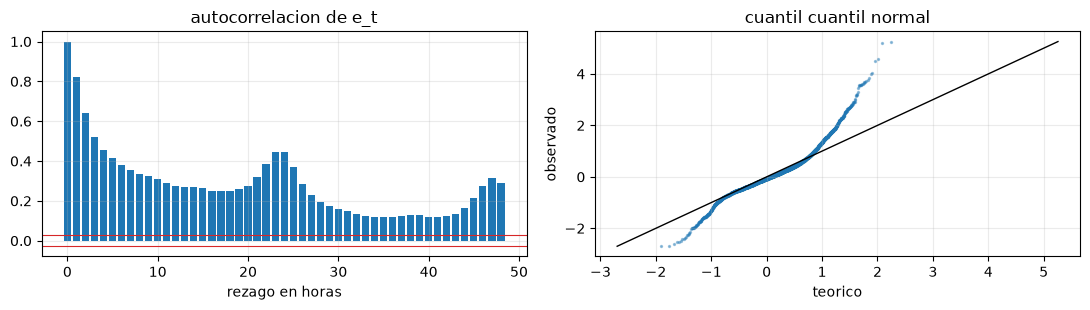

In [46]:
acf = [1.0] + [float(np.corrcoef(e_mon[:-k], e_mon[k:])[0, 1]) for k in range(1, 49)]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].bar(range(len(acf)), acf, width=0.8)
ax[0].axhline(2 / np.sqrt(len(e_mon)), color="tab:red", lw=0.8)
ax[0].axhline(-2 / np.sqrt(len(e_mon)), color="tab:red", lw=0.8)
ax[0].set_title("autocorrelacion de e_t"); ax[0].set_xlabel("rezago en horas")

from math import erf

malla = np.linspace(-6.0, 6.0, 4001)
phi = np.array([0.5 * (1.0 + erf(x / np.sqrt(2.0))) for x in malla])

z = np.sort(e_mon)
p = (np.arange(1, len(z) + 1) - 0.5) / len(z)
teorico = np.interp(p, phi, malla) * np.sqrt(SIGMA2) + np.mean(e_mon)

ax[1].scatter(teorico, z, s=2, alpha=0.4)
lim = [min(z.min(), teorico.min()), max(z.max(), teorico.max())]
ax[1].plot(lim, lim, color="black", lw=1.0)
ax[1].set_title("cuantil cuantil normal"); ax[1].set_xlabel("teorico"); ax[1].set_ylabel("observado")
fig.tight_layout()

## 14. Limitaciones y pregunta de investigacion

**Lo que el modelo no puede decidir por si solo.** Una observacion con densidad predictiva baja no
prueba que el sensor este danado. Puede corresponder a un episodio real de contaminacion, y la
seccion 7 mostro que las alertas se agrupan justamente en los meses de mayor contaminacion. La
separacion entre anomalia del instrumento y evento ambiental requiere contrastar contra el
analizador de referencia y contra los demas sensores en la misma hora, no solo contra el modelo. En
operacion, sin analizador de referencia, la unica senal disponible es la coherencia entre sensores:
un episodio ambiental los afecta a todos y una averia afecta a uno.

**Lo que el cuaderno si establece.** La actualizacion bayesiana recursiva de la seccion 3.4 funciona
tal como el capitulo la describe: con dos estadisticas suficientes se mantiene la posterior del
sesgo hora a hora, la predictiva permite cuantificar la sorpresa de cada dato y la comparacion con
el MLE muestra el papel de la previa en muestra pequena. Los diagnosticos muestran ademas en que
puntos el modelo del capitulo se queda corto para este sensor: colas pesadas, dependencia temporal,
varianza no constante y sesgo estacional.

**Pregunta de investigacion futura.** Los cinco sensores del dispositivo comparten temperatura,
humedad y episodios ambientales, y la seccion 11 mostro que sus respuestas estan fuertemente
correlacionadas. La pregunta que se abre es si un modelo bayesiano conjunto, en el que el sesgo
de cada sensor sea una variable de estado que evoluciona en el tiempo y las cinco compartan una
componente comun, permite separar la deriva propia de un sensor (que se mueve sola) del episodio
ambiental (que mueve a los cinco a la vez), y con que anticipacion respecto del criterio univariante
de este cuaderno. La misma maquinaria de la seccion 3.4.3, la normal multivariante con previa
normal, es el punto de partida, y el EM de la seccion 3.9 el mecanismo para estimar la covarianza
compartida cuando faltan lecturas.